# 03 — Frozen baseline results

**What you are looking at:** the official benchmark table — every classical
strategy evaluated at every cost level on the frozen 100,000-path TEST set,
with bootstrap confidence intervals. This is a *sign-off* notebook: it is one
of the few places allowed to touch TEST paths (the code guard demands an
explicit `final=True`). The table it writes is hashed into the manifest, and
Stage 4's learned policy will be judged against this exact artifact. Every
headline number is registered in `CLAIMS.md` and re-verified by the final
cell.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import deep_hedging
from deep_hedging import manifest
from deep_hedging.claims import verify_claims
from deep_hedging.baselines import (
    bs_delta_strategy, load_calibration,
    make_leland_strategy, make_whalley_wilmott_strategy,
)
from deep_hedging.evaluate import (
    PATH_SET_SEEDS, PATH_SET_SIZES, CANONICAL, CANONICAL_GBM,
    generate_path_set, path_set_fingerprint,
    build_baseline_table, baseline_table_to_markdown,
)

ROOT = Path(deep_hedging.__file__).resolve().parents[2]
RESULTS = ROOT / "results"
calib = load_calibration(RESULTS / "baseline_calibration.json")

## The exam paper: three sealed path sets

**What you are looking at:** the TRAIN/VAL/TEST discipline. All development
happens on TRAIN and VAL; TEST exists only to produce final published
numbers, and the code refuses to hand it over without `final=True` — we
demonstrate the refusal below. Each pool's SHA-256 fingerprint is recorded in
`results/path_sets.json` (and hashed into the manifest), so anyone can
regenerate the pools from their seeds and prove they got bit-identical
paths.

In [2]:
try:
    generate_path_set("TEST")
    raise RuntimeError("guard failed to fire")
except PermissionError as e:
    print(f"guard works: PermissionError: {e}")

path_sets = {}
for name in ("TRAIN", "VAL", "TEST"):
    paths = generate_path_set(name, final=(name == "TEST"))
    path_sets[name] = {
        "seed": PATH_SET_SEEDS[name],
        "n_paths": PATH_SET_SIZES[name],
        "n_steps": CANONICAL["n_steps"],
        "horizon": CANONICAL["horizon"],
        "gbm": vars(CANONICAL_GBM),
        "sha256": path_set_fingerprint(paths),
    }
    print(f"{name:>5}: {PATH_SET_SIZES[name]:>7,} paths  sha256 {path_sets[name]['sha256'][:16]}…")

assert len({v["sha256"] for v in path_sets.values()}) == 3, "pools must be disjoint"
(RESULTS / "path_sets.json").write_text(json.dumps(path_sets, indent=2, sort_keys=True) + "\n")
print("recorded to results/path_sets.json")

guard works: PermissionError: TEST paths are reserved for final sign-off (results notebooks and published-metrics verification tests). Pass final=True only there; use TRAIN or VAL for development.


TRAIN: 100,000 paths  sha256 db20bf20d0b2cd9f…
  VAL:  50,000 paths  sha256 ea30448b397a2956…


 TEST: 100,000 paths  sha256 2d031716b16fa24e…
recorded to results/path_sets.json


## The frozen baseline table

**What you are looking at:** 3 strategies × 4 cost levels on the TEST set.
Each strategy uses its *calibrated* parameter for that cost level (fairness
protocol, notebook 02). Columns: mean and standard deviation of terminal
P&L; CVaR(95%) and CVaR(99%) of loss — the average of the worst 5% and 1% of
outcomes — each with a seeded 1000-resample bootstrap CI; and mean turnover
(total shares traded). Takes about a minute.

In [3]:
def ww_factory(bps):
    return make_whalley_wilmott_strategy(
        calib["per_cost_level"][str(bps)]["whalley_wilmott"]["risk_aversion"])

def leland_factory(bps):
    return make_leland_strategy(
        calib["per_cost_level"][str(bps)]["leland"]["adjustment_scale"])

factories = {
    "bs_delta": lambda bps: bs_delta_strategy,
    "leland": leland_factory,
    "whalley_wilmott": ww_factory,
}

test_paths = generate_path_set("TEST", final=True)
table = build_baseline_table(
    test_paths, strategy_factories=factories,
    meta={"path_set": "TEST", "calibration": "results/baseline_calibration.json"},
)

markdown = baseline_table_to_markdown(table)
(RESULTS / "baseline_table.json").write_text(json.dumps(table, indent=2, sort_keys=True) + "\n")
(RESULTS / "baseline_table.md").write_text(markdown)
print(markdown)

| cost (bps) | strategy | mean P&L | std | CVaR95 | CVaR95 95% CI | CVaR99 | CVaR99 95% CI | turnover |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | bs_delta | -0.0007 | 0.4345 | 1.0017 | [0.9903, 1.0138] | 1.4727 | [1.4458, 1.4971] | 3.510 |
| 0 | leland | -0.0007 | 0.4345 | 1.0017 | [0.9903, 1.0138] | 1.4727 | [1.4458, 1.4971] | 3.510 |
| 0 | whalley_wilmott | -0.0007 | 0.4345 | 1.0017 | [0.9903, 1.0138] | 1.4727 | [1.4458, 1.4971] | 3.510 |
| 5 | bs_delta | -0.1781 | 0.4432 | 1.2365 | [1.2243, 1.2486] | 1.7280 | [1.7005, 1.7529] | 3.510 |
| 5 | leland | -0.1661 | 0.5015 | 1.0635 | [1.0565, 1.0712] | 1.3717 | [1.3524, 1.3900] | 3.285 |
| 5 | whalley_wilmott | -0.1479 | 0.4601 | 1.2177 | [1.2057, 1.2302] | 1.6973 | [1.6718, 1.7224] | 2.896 |
| 20 | bs_delta | -0.7101 | 0.5028 | 1.9683 | [1.9549, 1.9815] | 2.5163 | [2.4869, 2.5433] | 3.510 |
| 20 | leland | -0.6494 | 0.5221 | 1.6067 | [1.5991, 1.6149] | 1.9242 | [1.9054, 1.9420] | 3.212 |
| 20 | whalley_wilmott | -0.46

## Why the band beats naive delta as costs rise — and an honest wrinkle

**What you are looking at:** CVaR(95%) against cost level. Naive delta's
turnover is *fixed* (it always trades to delta, ~3.5 shares over the option's
life), so its cost bill — and its loss tail — grows linearly and fastest.
The band adapts: at higher costs its calibrated width grows, cutting turnover
to nearly half, so its curve rises much more slowly. **The wrinkle:** on
CVaR(95%) *alone*, calibrated Leland is slightly better than the band at
every positive cost level — Leland keeps a tighter error distribution, while
the band wins on mean P&L and turnover (and hence on the combined mean–CVaR
objective it was calibrated for). The claims register states exactly this;
no "band dominates" overclaim is made. This subtlety is the bar Stage 4's
learned policy has to clear.

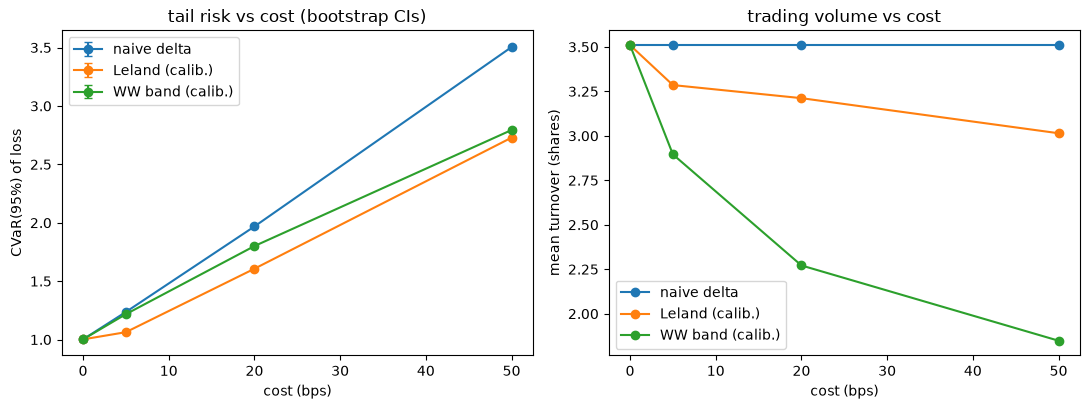

In [4]:
rows = table["rows"]
costs = sorted({r["cost_bps"] for r in rows})
names = {"bs_delta": "naive delta", "leland": "Leland (calib.)", "whalley_wilmott": "WW band (calib.)"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for strat, label in names.items():
    sel = [r for r in rows if r["strategy"] == strat]
    sel.sort(key=lambda r: r["cost_bps"])
    cv = [r["cvar95"] for r in sel]
    lo = [r["cvar95"] - r["cvar95_ci"][0] for r in sel]
    hi = [r["cvar95_ci"][1] - r["cvar95"] for r in sel]
    ax1.errorbar(costs, cv, yerr=[lo, hi], marker="o", capsize=3, label=label)
    ax2.plot(costs, [r["turnover"] for r in sel], marker="o", label=label)
ax1.set_xlabel("cost (bps)"); ax1.set_ylabel("CVaR(95%) of loss"); ax1.set_title("tail risk vs cost (bootstrap CIs)")
ax2.set_xlabel("cost (bps)"); ax2.set_ylabel("mean turnover (shares)"); ax2.set_title("trading volume vs cost")
ax1.legend(); ax2.legend()
plt.tight_layout(); plt.show()

## Sanity asserts and the frozen-claims check

**What you are looking at:** the harness check (at zero cost all three
strategies collapse to plain delta hedging, so their rows must be
*identical*, and mean P&L must be zero within 4 standard errors), the
orderings (every calibrated baseline beats naive delta on CVaR95 at positive
cost), and finally `verify_claims`, which cross-checks every number above
against `CLAIMS.md`. The artifacts are then hashed into the manifest — the
freeze that later stages compare against.

In [5]:
zero = [r for r in rows if r["cost_bps"] == 0.0]
for r in zero[1:]:
    for key in ("mean_pnl", "std_pnl", "cvar95", "cvar99", "turnover"):
        assert r[key] == zero[0][key]
se = zero[0]["std_pnl"] / np.sqrt(table["config"]["n_paths"])
assert abs(zero[0]["mean_pnl"]) < 4 * se
print(f"zero-cost coincidence OK; |mean pnl| = {abs(zero[0]['mean_pnl']):.4f} < 4 SE = {4*se:.4f}")

by = {(r["cost_bps"], r["strategy"]): r for r in rows}
for bps in (5.0, 20.0, 50.0):
    assert by[(bps, "whalley_wilmott")]["cvar95"] < by[(bps, "bs_delta")]["cvar95"]
    assert by[(bps, "leland")]["cvar95"] < by[(bps, "bs_delta")]["cvar95"]
    assert by[(bps, "whalley_wilmott")]["turnover"] < by[(bps, "bs_delta")]["turnover"]
print("orderings OK: calibrated baselines beat naive delta on CVaR95 at every positive cost")

computed = {}
tag = {"bs_delta": "DELTA", "leland": "LELAND", "whalley_wilmott": "WW"}
for r in rows:
    if r["cost_bps"] in (20.0, 50.0):
        computed[f"BT{int(r['cost_bps'])}-{tag[r['strategy']]}-CVAR95"] = r["cvar95"]
    if r["cost_bps"] == 50.0:
        computed[f"BT50-{tag[r['strategy']]}-TURNOVER"] = r["turnover"]
print(verify_claims("03_baseline_results", computed))

manifest.add([RESULTS / "baseline_table.json", RESULTS / "baseline_table.md",
              RESULTS / "path_sets.json"], allow_change=False)
print(f"manifest updated: {len(manifest.read_manifest())} artifacts tracked")
print("03_baseline_results: all assertions passed")

zero-cost coincidence OK; |mean pnl| = 0.0007 < 4 SE = 0.0055
orderings OK: calibrated baselines beat naive delta on CVaR95 at every positive cost
verified 9 claims for 03_baseline_results (atol=0.0001)
manifest updated: 5 artifacts tracked
03_baseline_results: all assertions passed
